In [12]:
import sys

sys.path.append("../../BayesFlow")
sys.path.append("../")

import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pickle

import keras

import bayesflow as bf


# Plot individual effects? 
plot_individual_effects = False

network_names = [
    'initial_priors_sdr_fixed',
    'updated_priors_sdr_fixed',
    'initial_priors_sdr_estimated',
    'updated_priors_sdr_estimated',
]


parent_dir = os.path.dirname(os.getcwd())



from dmc import dmc_helpers
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# load mode specifications


# IDs that were used to update the priors
train_idx = np.array([1761, 5281,  845, 1824, 5575, 8755, 8026, 8704, 7813, 1597, 7756,
       7624, 1108,  837, 7828, 6055,  833, 1821,  985, 1582, 8311, 8785,
       3286, 4264, 6583, 3487, 6565, 6427, 1430, 6361, 5815, 6262, 5332,
       1614, 7939, 6214])



In [13]:
# load narrow and wide data
narrow_data = pd.read_csv(parent_dir + '/empirical_data/experiment_data_narrow.csv')
wide_data = pd.read_csv(parent_dir + '/empirical_data/experiment_data_wide.csv')

# IDs that were used to update the priors
train_idx = np.array([1761, 5281,  845, 1824, 5575, 8755, 8026, 8704, 7813, 1597, 7756,
       7624, 1108,  837, 7828, 6055,  833, 1821,  985, 1582, 8311, 8785,
       3286, 4264, 6583, 3487, 6565, 6427, 1430, 6361, 5815, 6262, 5332,
       1614, 7939, 6214])

# exclude training IDs
narrow_data = narrow_data[~narrow_data['participant'].isin(train_idx)]
wide_data = wide_data[~wide_data['participant'].isin(train_idx)]


In [14]:
data_path = parent_dir + '/data_complete/empirical_estimates/'


/home/administrator/Documents/amortized-dmc/plot_scripts/../dmc/dmc_helpers.py:620: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  samples1['sample_id'] = np.tile(np.random.permutation(num_samples), parts.shape[0])
/home/administrator/Documents/amortized-dmc/plot_scripts/../dmc/dmc_helpers.py:621: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  samples2['sample_id'] = np.tile(np.random.permutation(num_samples), parts.shape[0])
/home/administrator/Documents/amortized-dmc/plot_scripts/../dmc/dmc_helpers.py:620: 

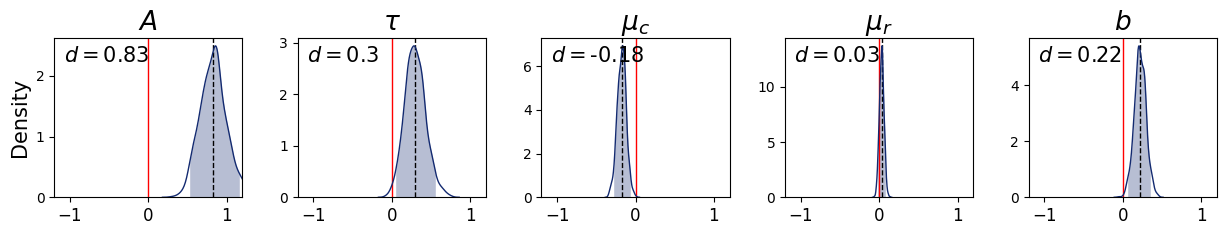

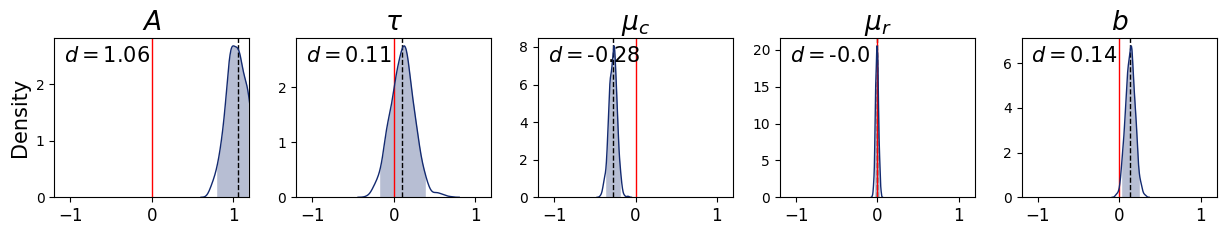

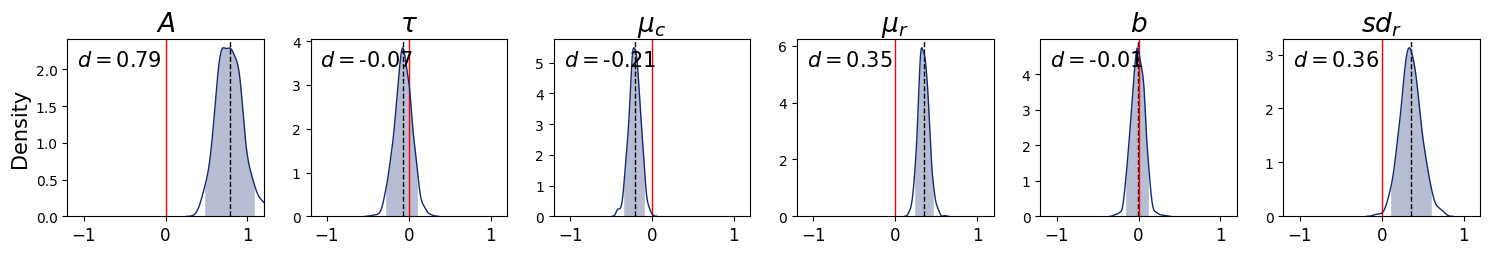

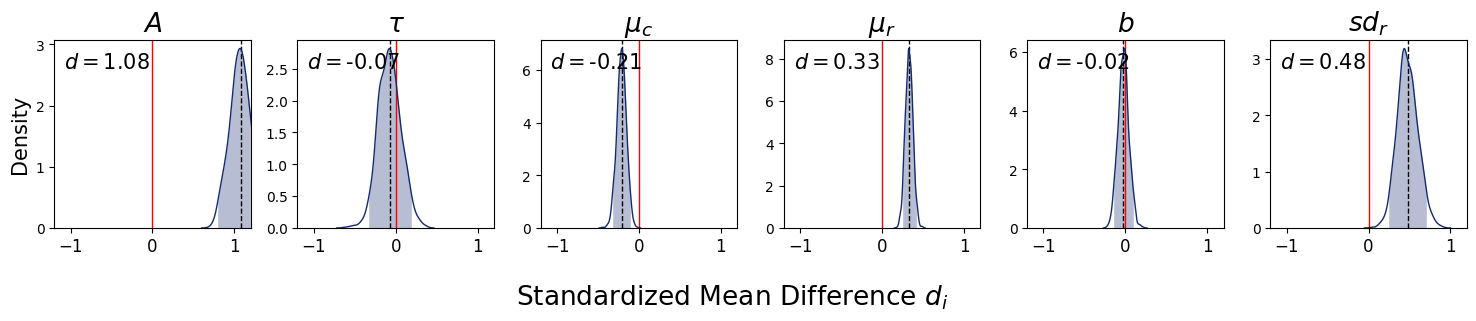

In [26]:
for network_name in network_names:

    data_samples = pd.read_csv(data_path + network_name + '.csv')

    data_samples = data_samples[~data_samples['participant'].isin(train_idx)]
    
    samples_wide = data_samples[data_samples['spacing'] == 'wide']

    samples_narrow = data_samples[data_samples['spacing'] == 'narrow']
    # load mode specifications
    model_specs_path = parent_dir + '/model_specs/model_specs_' + network_name + '.pickle'
    with open(model_specs_path, 'rb') as file:
        model_specs = pickle.load(file)

    # concatenate sample data from both spacing conditions
    samples_complete = pd.concat((samples_wide, samples_narrow))

    # extract list of all participants
    parts = samples_complete["participant"].unique()

    # get parameter names
    param_names = model_specs['simulation_settings']['param_names']

    # define directory
    network_plot_folder = parent_dir + "/plots/experimental_effects/" 

    if not os.path.exists(network_plot_folder):
        os.makedirs(network_plot_folder)

    # define plot colors:
    hue_order = ["narrow", "wide"]
    palette = {"narrow": '#132a70', "wide": '#FF6361'}

    if plot_individual_effects:
        for i, part in enumerate(parts):
            
            fig, axes = plt.subplots(1,len(param_names), figsize=(10,3))
            
            axes = axes.flatten()


            for p, ax in zip(param_names, axes):
                
                part_data = samples_complete[samples_complete["participant"]==part]
                part_data = pd.DataFrame(part_data.reset_index(drop=True))

                #dat = pd.DataFrame(part_data.groupby(['participant', 'spacing']).agg(['mean', 'std']))
                
                sns.pointplot(data=part_data, ax=ax, x="spacing", y=p, color='#132a70',errorbar="sd")

                for patch in ax.patches:
                    facecolor = patch.get_facecolor()
                    patch.set_facecolor((*facecolor[:3], 0.3)) 
                ax.set_ylabel("")

                suff = "$\\" if p in ["tau", "mu_c", "mu_r"] else "$"

                label = suff + p + "$"

                ax.set_title(label)
                    
            fig.suptitle(str(part))    
            fig.tight_layout()
            fig.savefig(network_plot_folder + "/experimental_effects_" + network_name + str(part) + ".png")

    if network_name == 'initial_priors_sdr_fixed' or network_name == 'updated_priors_sdr_fixed':
        figsize=(12.5,2.6)

    elif network_name == 'initial_priors_sdr_estimated':
        figsize=(15,2.8)
    else:
        figsize=(15,3.2)

    if network_name == 'updated_priors_sdr_estimated':

        supxlabel='Standardized Mean Difference $d_i$'

    else:
        supxlabel=''

    data, fig = dmc_helpers.smd_samples(samples_narrow, 
                                        samples_wide, 
                                        param_names, 
                                        num_samples=1000, 
                                        subj_id='participant', 
                                        hdi_color='white', 
                                        sharex=False,
                                        figsize=figsize,
                                        fontsize=19,
                                        supxlabel=supxlabel)

    fig.savefig(network_plot_folder + "/experimental_effects_" + network_name + "_post_samples_difference.png")

In [16]:
network_plot_folder

'/home/administrator/Documents/amortized-dmc/plots/experimental_effects/'